# Análisis y Proyección de Ventas - Walmart

## Introducción

En el entorno actual del retail, la capacidad de analizar el comportamiento de las ventas y anticipar la demanda es fundamental para la toma de decisiones estratégicas. Factores como la estacionalidad, los eventos especiales y las características propias de cada tienda influyen directamente en el desempeño comercial.

Este proyecto tiene como objetivo analizar las ventas históricas de distintas tiendas y departamentos, integrando información adicional como variables económicas y eventos festivos, con el fin de identificar patrones relevantes y generar insights de negocio.

A partir de este análisis, se busca no solo comprender la dinámica de las ventas, sino también desarrollar un enfoque de predicción que permita anticipar tendencias futuras, facilitando la planificación operativa, la gestión de inventarios y la optimización de recursos.

El enfoque del proyecto combina análisis exploratorio de datos, interpretación de resultados desde una perspectiva de negocio y la aplicación de modelos de predicción, con el propósito de generar información clara, útil y accionable.

## Descripción de las variables

El dataset utilizado contiene información histórica de ventas semanales a nivel de tienda y departamento, complementada con variables económicas, operativas y comerciales que permiten analizar el comportamiento del negocio desde diferentes perspectivas.

A continuación, se describen las principales variables:

###  Identificación

- **Store**: Identificador único de la tienda.
- **Dept**: Identificador del departamento dentro de cada tienda.

###  Variables de tiempo

- **Date**: Fecha correspondiente a la semana de registro de ventas.
- **IsHoliday**: Indica si la semana corresponde a un periodo festivo (True/False).

###  Variable objetivo

- **Weekly_Sales**: Ventas semanales registradas para cada combinación de tienda y departamento.

###  Variables operativas y económicas

- **Temperature**: Temperatura promedio de la semana.
- **Fuel_Price**: Precio del combustible, que puede influir en el comportamiento del consumidor.
- **CPI**: Índice de Precios al Consumidor (Consumer Price Index), indicador de inflación.
- **Unemployment**: Tasa de desempleo en la región.

###  Variables comerciales (promociones)

- **MarkDown1 - MarkDown5**: Representan diferentes tipos de inversiones en promociones o descuentos aplicados en determinados periodos. Estas variables reflejan el esfuerzo comercial para incentivar las ventas.

###  Características de la tienda

- **Type**: Clasificación de la tienda (por ejemplo: A, B o C), asociada a su tamaño o formato.
- **Size**: Tamaño de la tienda, generalmente relacionado con su capacidad operativa y volumen de ventas.

---

Esta combinación de variables permite analizar no solo el comportamiento histórico de las ventas, sino también el impacto de factores externos, características de las tiendas y estrategias comerciales sobre el desempeño del negocio.

## Carga de datos

Los datos pueden descargarse desde Kaggle:
Walmart Recruiting - Store Sales Forecasting

In [1]:
import pandas as pd

train = pd.read_csv("data/train.csv")
features = pd.read_csv("data/features.csv")
stores = pd.read_csv("data/stores.csv")


## Estructurar Tabla

In [2]:
df = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
df = df.merge(stores, on='Store', how='left')

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


## Limpieza

Se rellenan los NA con 0 ya que no hay promocion, no hay gasto

In [3]:
markdown_cols = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']

df[markdown_cols] = df[markdown_cols].fillna(0)
df.head()


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315


# Análisis

## 1. Ventas por tienda

Se observa que un grupo reducido de tiendas concentra la mayor parte de las ventas totales, lo que sugiere diferencias significativas en tamaño, ubicación o demanda entre establecimientos.

In [4]:
sales_by_store = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
sales_by_store.head()

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64

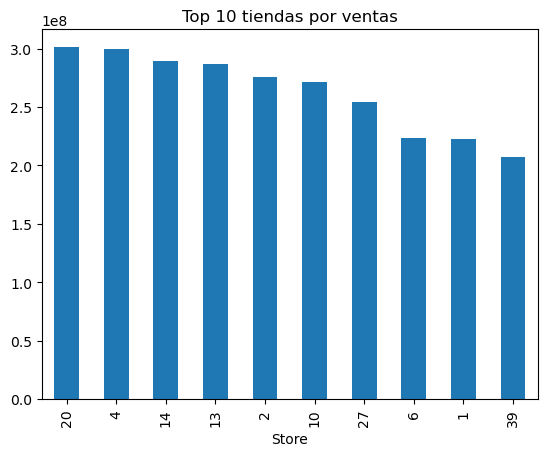

In [6]:
import matplotlib.pyplot as plt

sales_by_store.head(10).plot(kind='bar')
plt.title("Top 10 tiendas por ventas")
plt.show()

## 2.Ventas en festivos vs normales

Las ventas muestran variaciones significativas durante periodos festivos, lo que indica la importancia de estos eventos en la planificación comercial y logística.

In [7]:
holiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean()

holiday_sales

IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

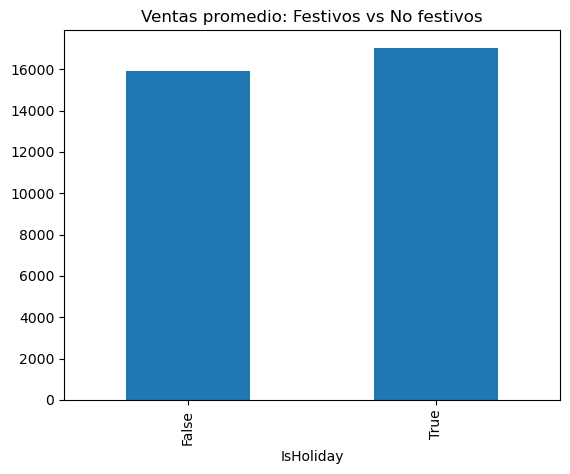

In [8]:
holiday_sales.plot(kind='bar')
plt.title("Ventas promedio: Festivos vs No festivos")
plt.show()

## 3.Evolución en el tiempo

Se identifican patrones estacionales en las ventas, lo que permite anticipar periodos de alta y baja demanda para una mejor gestión de inventarios.

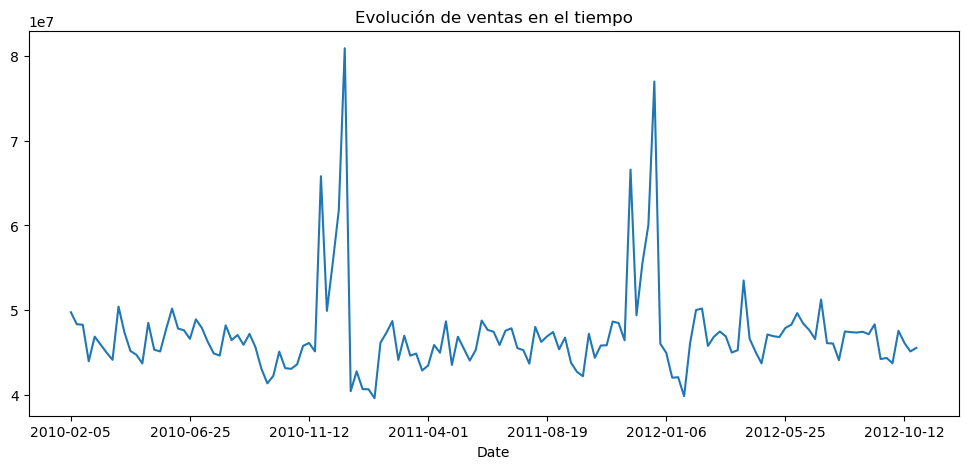

In [9]:
sales_time = df.groupby('Date')['Weekly_Sales'].sum()

sales_time.plot(figsize=(12,5))
plt.title("Evolución de ventas en el tiempo")
plt.show()

## 4.Ventas por tipo de tienda

Se observan diferencias en el desempeño según el tipo de tienda, lo que sugiere que factores como el tamaño, ubicación o formato del establecimiento impactan directamente en el nivel de ventas.

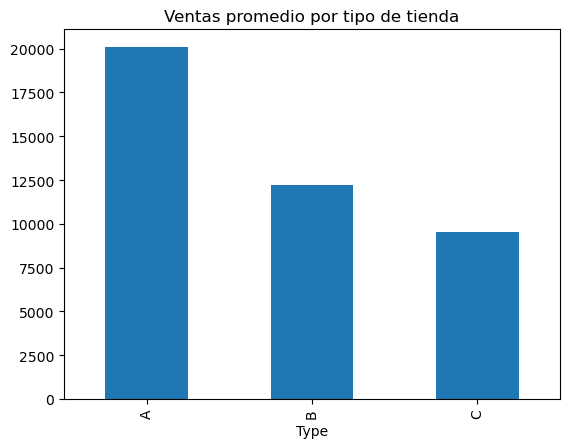

In [10]:
sales_type = df.groupby('Type')['Weekly_Sales'].mean()

sales_type.plot(kind='bar')
plt.title("Ventas promedio por tipo de tienda")
plt.show()

## 5.Top departamentos

Algunos departamentos concentran una proporción significativa de las ventas, lo que indica oportunidades para enfocar estrategias comerciales y optimizar el portafolio de productos

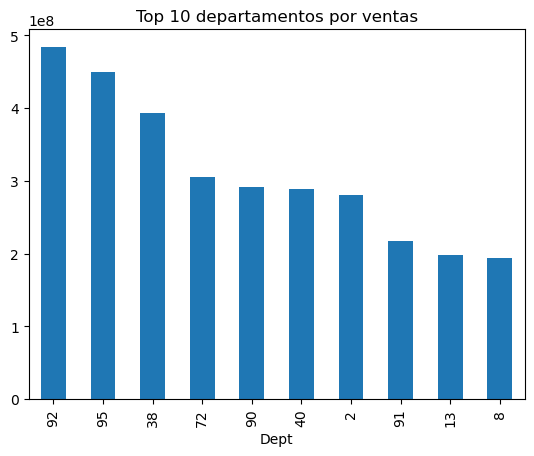

In [11]:
top_dept = df.groupby('Dept')['Weekly_Sales'].sum().sort_values(ascending=False)

top_dept.head(10).plot(kind='bar')
plt.title("Top 10 departamentos por ventas")
plt.show()

## 6. Correlograma

## Conclusión del análisis de correlación

La matriz de correlación muestra que Ventas semanales no presenta una relación lineal fuerte con una única variable explicativa. La variable Tamaño es una de las que muestra una asociación positiva más relevante, lo cual indica que las tiendas de mayor tamaño tienden a generar mayores ventas.

Por otro lado, las variables promocionales MarkDown1 a MarkDown5 presentan algunas correlaciones entre sí, lo que sugiere que ciertas campañas comerciales pudieron aplicarse de forma conjunta. Sin embargo, su relación directa con las ventas semanales no es suficientemente fuerte desde una perspectiva lineal.

Las variables económicas y externas, como CPI, Unemployment, Temperature y Fuel_Price, muestran relaciones bajas con las ventas, por lo que su impacto podría depender de interacciones con otras variables, patrones temporales o características específicas de cada tienda y departamento.

En conjunto, estos resultados sugieren que el comportamiento de las ventas es multifactorial y requiere un análisis más amplio que considere variables comerciales, temporales y operativas de manera conjunta.

In [12]:
num_df = df.select_dtypes(include=['int64', 'float64'])

In [13]:
corr_matrix = num_df.corr()

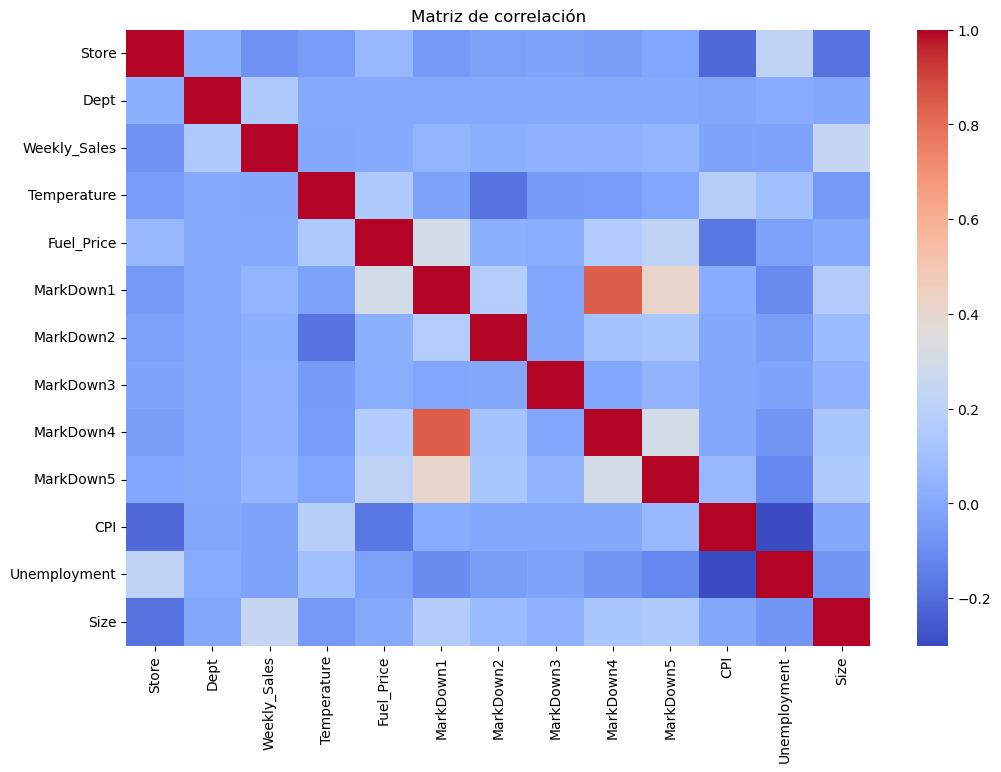

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Matriz de correlación")
plt.show()

## Enfoque de modelado

A partir del análisis exploratorio y de la matriz de correlación, se observa que Ventas semanales no presenta una relación lineal fuerte con una única variable explicativa. Esto sugiere que las ventas semanales no pueden ser explicadas adecuadamente mediante un modelo simple basado solo en correlaciones individuales.

Dado que la variable objetivo corresponde a ventas semanales y el dataset contiene una estructura temporal clara, inicialmente se abordó el problema desde un enfoque de series de tiempo. Para ello, se construyó un modelo SARIMA sobre las ventas agregadas por fecha, con el fin de capturar patrones de tendencia y estacionalidad en el comportamiento general de las ventas.

Sin embargo, el dataset también tiene una estructura multidimensional, ya que las ventas están segmentadas por tienda, departamento y semana, además de incluir variables comerciales, económicas y características propias de cada tienda. Por esta razón, el análisis se complementó con un modelo Random Forest, el cual permite incorporar múltiples variables explicativas y capturar relaciones no lineales entre ellas.

Este enfoque combinado permite analizar el problema desde dos perspectivas: por un lado, el comportamiento temporal agregado de las ventas mediante SARIMA; y por otro, la influencia de variables como departamento, tamaño de tienda, ubicación, promociones, festivos y condiciones económicas mediante Random Forest.

De esta manera, el proyecto no se limita a un único enfoque predictivo, sino que compara modelos con características diferentes para obtener una visión más completa del comportamiento de las ventas y sus principales factores explicativos.

Es importante señalar que los resultados de SARIMA y Random Forest no son directamente comparables, ya que SARIMA fue aplicado sobre ventas agregadas semanales, mientras que Random Forest fue entrenado a nivel de tienda, departamento y semana. Por lo tanto, cada modelo responde a una perspectiva diferente del problema.

## Modelo SARIMA

El modelo SARIMA permite capturar componentes temporales relevantes de la serie, incluyendo tendencia y estacionalidad. Su desempeño fue evaluado comparando las ventas reales del periodo de prueba con las ventas pronosticadas.

Los resultados obtenidos fueron los siguientes:

- **MAE:** 1,703,732.76  
- **RMSE:** 2,129,751.12  
- **MAPE:** 3.68%

El **MAPE de 3.68%** indica que, en promedio, el error porcentual del modelo respecto a las ventas reales es relativamente bajo. Esto sugiere que el modelo SARIMA logra una aproximación adecuada al comportamiento agregado de las ventas semanales.

Sin embargo, aunque el desempeño general es positivo, el MAE y el RMSE muestran que existen desviaciones absolutas relevantes en términos monetarios. Esto es esperable debido al alto volumen agregado de ventas y a posibles variaciones asociadas a semanas especiales, promociones o cambios en la demanda.

En conclusión, el modelo SARIMA representa una base sólida para el pronóstico de ventas agregadas. No obstante, dado que las ventas de Walmart están segmentadas por tienda y departamento, una mejora futura podría consistir en desarrollar modelos específicos por tienda, departamento o incorporar variables externas como promociones, festivos, tamaño de tienda y condiciones económicas.

El modelo SARIMA utilizado considera una estructura autorregresiva y de media móvil, junto con diferenciación regular y estacional. Dado que los datos son semanales, se utiliza una estacionalidad de 52 periodos, equivalente aproximadamente a un ciclo anual.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df['Date'] = pd.to_datetime(df['Date'])

sales_ts = df.groupby('Date')['Weekly_Sales'].sum().sort_index()

sales_ts.head()

Date
2010-02-05    49750740.50
2010-02-12    48336677.63
2010-02-19    48276993.78
2010-02-26    43968571.13
2010-03-05    46871470.30
Name: Weekly_Sales, dtype: float64

In [16]:
sales_ts = sales_ts.asfreq('W-FRI')

In [17]:
train_size = int(len(sales_ts) * 0.8)

train_ts = sales_ts.iloc[:train_size]
test_ts = sales_ts.iloc[train_size:]

print("Train:", train_ts.shape)
print("Test:", test_ts.shape)

Train: (114,)
Test: (29,)


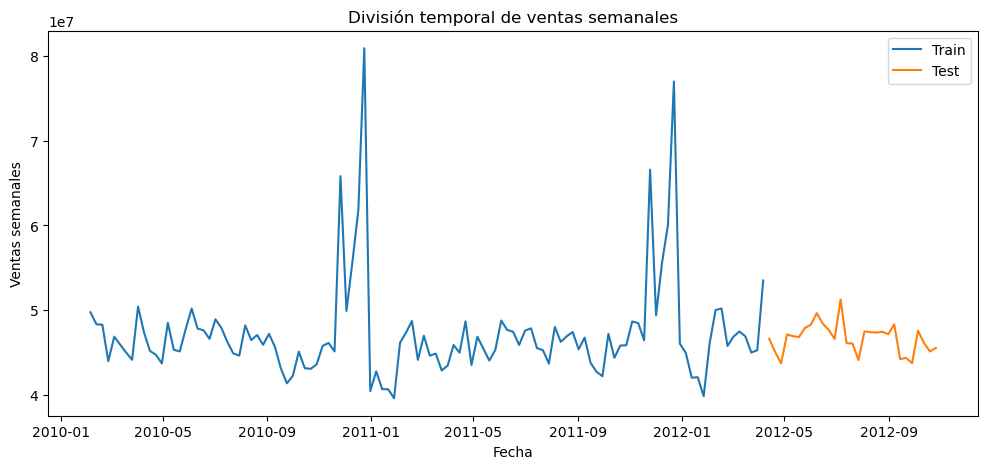

In [18]:
plt.figure(figsize=(12,5))
plt.plot(train_ts, label='Train')
plt.plot(test_ts, label='Test')
plt.title("División temporal de ventas semanales")
plt.xlabel("Fecha")
plt.ylabel("Ventas semanales")
plt.legend()
plt.show()

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train_ts,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = model.fit(disp=False)

print(sarima_result.summary())

C:\Users\Admin\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  114
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 52)   Log Likelihood                -112.408
Date:                            Tue, 12 May 2026   AIC                            234.817
Time:                                    18:59:44   BIC                            234.546
Sample:                                02-05-2010   HQIC                           231.474
                                     - 04-06-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4030      7.107     -0.057      0.955     -14.333      13.527
ma.L1         -0.9235      3.787   

In [20]:
forecast = sarima_result.get_forecast(steps=len(test_ts))

forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

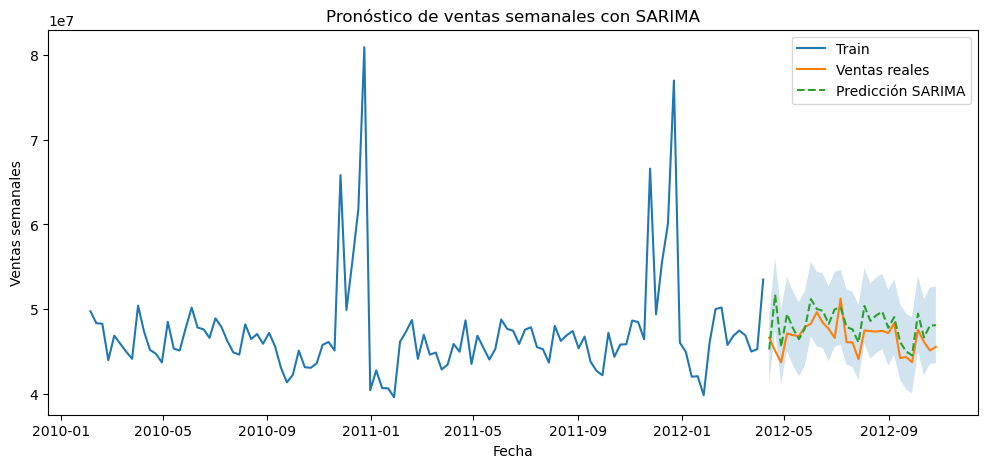

In [21]:
plt.figure(figsize=(12,5))

plt.plot(train_ts, label='Train')
plt.plot(test_ts, label='Ventas reales')
plt.plot(forecast_mean, label='Predicción SARIMA', linestyle='--')

plt.fill_between(
    forecast_ci.index,
    forecast_ci.iloc[:, 0],
    forecast_ci.iloc[:, 1],
    alpha=0.2
)

plt.title("Pronóstico de ventas semanales con SARIMA")
plt.xlabel("Fecha")
plt.ylabel("Ventas semanales")
plt.legend()
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_sarima = mean_absolute_error(test_ts, forecast_mean)
rmse_sarima = np.sqrt(mean_squared_error(test_ts, forecast_mean))
mape_sarima = np.mean(np.abs((test_ts - forecast_mean) / test_ts)) * 100

print("MAE SARIMA:", mae_sarima)
print("RMSE SARIMA:", rmse_sarima)
print("MAPE SARIMA:", mape_sarima)

MAE SARIMA: 1703732.7645375703
RMSE SARIMA: 2129751.117818163
MAPE SARIMA: 3.678459754634584


## Modelo Random Forest

Además del modelo SARIMA, se implementó un modelo Random Forest Regressor con el objetivo de incorporar variables adicionales del negocio, tales como tienda, departamento, promociones, festivos, tamaño de tienda, variables económicas y variables temporales.

A diferencia de SARIMA, que se enfoca principalmente en el comportamiento histórico de la serie agregada, Random Forest permite capturar relaciones no lineales entre múltiples variables explicativas y las ventas semanales a nivel de tienda y departamento.

Los resultados obtenidos fueron:

- **MAE:** 2,191.54
- **RMSE:** 4,259.74
- **WMAE:** 2,212.10
- **MAPE:** No aplicable directamente, debido a la presencia de ventas iguales o cercanas a cero en algunas observaciones.

El **MAE** indica que, en promedio, el modelo presenta un error absoluto aproximado de **2,191.54 dólares por observación**. El **RMSE**, al ser mayor, evidencia la existencia de algunos errores más grandes en determinadas combinaciones de tienda, departamento y semana.

El **WMAE** obtenido fue de **2,212.10**, lo que permite evaluar el modelo considerando un mayor peso en las semanas festivas. Esta métrica es especialmente relevante en este dataset, ya que las semanas festivas pueden tener un impacto significativo en el comportamiento de las ventas.

La importancia de variables muestra que Dept es el factor más relevante para el modelo, seguido por Size, Store y Week. Esto sugiere que las ventas están fuertemente influenciadas por el tipo de departamento, el tamaño de la tienda, la ubicación o identidad del establecimiento y el comportamiento temporal de la demanda.

En conclusión, Random Forest permite capturar mejor la estructura multidimensional del dataset, ya que considera simultáneamente variables comerciales, temporales, económicas y características propias de cada tienda. No obstante, aunque el modelo presenta un desempeño razonable, futuras mejoras podrían incluir validación temporal más robusta, ajuste de hiperparámetros e incorporación de variables rezagadas para capturar mejor la dinámica histórica de las ventas.

Como mejora futura, se podría evaluar el tratamiento de variables como `Store` y `Dept` como variables categóricas, ya que actualmente funcionan como identificadores numéricos dentro del modelo.

In [23]:
df_model = df.copy()

df_model['Date'] = pd.to_datetime(df_model['Date'])

df_model['Year'] = df_model['Date'].dt.year
df_model['Month'] = df_model['Date'].dt.month
df_model['Week'] = df_model['Date'].dt.isocalendar().week.astype(int)

In [24]:
df_model = pd.get_dummies(df_model, columns=['Type'], drop_first=True)

In [25]:
features_rf = [
    'Store',
    'Dept',
    'IsHoliday',
    'Temperature',
    'Fuel_Price',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5',
    'CPI',
    'Unemployment',
    'Size',
    'Year',
    'Month',
    'Week',
    'Type_B',
    'Type_C'
]

X = df_model[features_rf]
y = df_model['Weekly_Sales']

In [26]:
df_model = df_model.sort_values('Date')

split_date = df_model['Date'].quantile(0.8)

train_rf = df_model[df_model['Date'] <= split_date]
test_rf = df_model[df_model['Date'] > split_date]

X_train = train_rf[features_rf]
y_train = train_rf['Weekly_Sales']

X_test = test_rf[features_rf]
y_test = test_rf['Weekly_Sales']

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,15
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rf_pred = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, rf_pred)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred))
mape_rf = np.mean(np.abs((y_test - rf_pred) / y_test)) * 100

print("MAE Random Forest:", mae_rf)
print("RMSE Random Forest:", rmse_rf)
print("MAPE Random Forest:", mape_rf)

MAE Random Forest: 2191.5386787116795
RMSE Random Forest: 4259.738843337677
MAPE Random Forest: inf


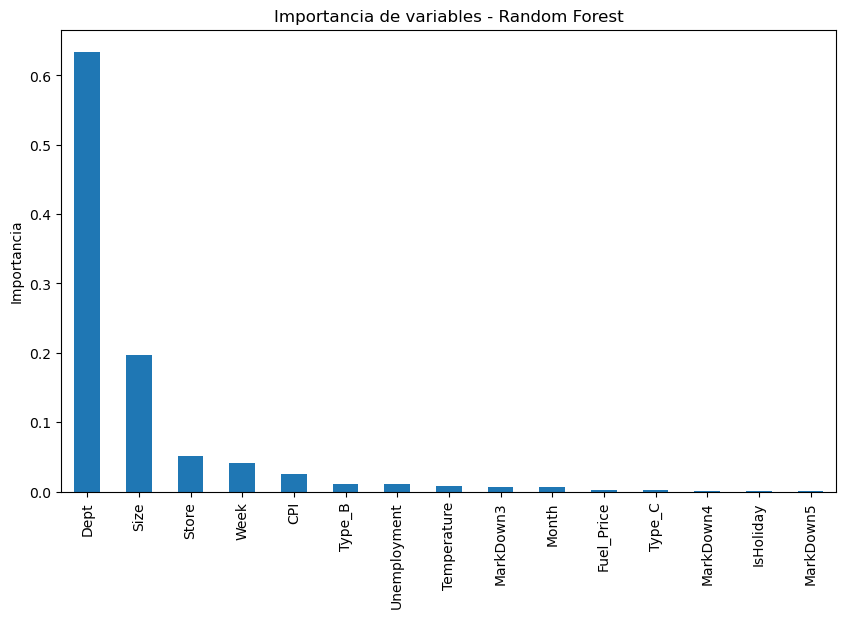

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(rf_model.feature_importances_, index=features_rf)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10,6))
importances.head(15).plot(kind='bar')
plt.title("Importancia de variables - Random Forest")
plt.ylabel("Importancia")
plt.show()

In [30]:
import numpy as np

weights = X_test['IsHoliday'].apply(lambda x: 5 if x == True else 1)

wmae_rf = np.sum(weights * np.abs(y_test - rf_pred)) / np.sum(weights)

print("WMAE Random Forest:", wmae_rf)

WMAE Random Forest: 2212.0972320362443


## Conclusión general

El análisis realizado permitió comprender el comportamiento de las ventas semanales de Walmart desde una perspectiva exploratoria, temporal y predictiva. A partir de la integración de información de ventas, características de tienda, variables económicas, promociones y semanas festivas, fue posible construir una visión más completa de los factores que influyen en el desempeño comercial.

En el análisis exploratorio se observó que las ventas no dependen de una única variable explicativa, sino de la interacción de múltiples factores. La matriz de correlación mostró relaciones lineales moderadas o bajas entre Ventas semanales y la mayoría de variables disponibles, destacándose principalmente el tamaño de la tienda y algunas variables asociadas a la estructura del negocio.

Desde el enfoque temporal, el modelo SARIMA permitió capturar el comportamiento agregado de las ventas semanales, considerando tendencia y estacionalidad. Este modelo obtuvo un **MAPE de 3.68%**, lo que indica una buena aproximación al comportamiento general de las ventas agregadas. Sin embargo, al trabajar sobre ventas totales por semana, este enfoque no captura completamente las diferencias existentes entre tiendas y departamentos.

Por otro lado, el modelo Random Forest permitió incorporar la estructura multidimensional del dataset, considerando variables como tienda, departamento, tamaño, semana, promociones, festivos y condiciones económicas. Los resultados obtenidos fueron un **MAE de 2,191.54**, un **RMSE de 4,259.74** y un **WMAE de 2,212.10**. La importancia de variables mostró que Dept, Size, Store y Week fueron los factores más relevantes para explicar las ventas, lo que confirma la importancia del tipo de departamento, el tamaño de la tienda, la identidad del establecimiento y el componente temporal.

En conjunto, los resultados sugieren que el comportamiento de las ventas en retail requiere un enfoque integral. Los modelos de series de tiempo son útiles para analizar y pronosticar el comportamiento agregado, mientras que los modelos de machine learning permiten capturar relaciones más complejas a nivel de tienda, departamento y semana.
